In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
load_dotenv()


True

In [3]:
llm = ChatOpenAI()

In [5]:
class JokeState(TypedDict):
    topic: str
    joke : str
    explanation: str


In [6]:
def create_joke(state:JokeState):
    prompt = f"write a joke on this topic {state['topic']}"
    response = llm.invoke(prompt).content
    return {'joke':response}

def generate_explanation(state:JokeState):  
    prompt = f"write an explanation for the joke {state['joke']}"
    response = llm.invoke(prompt).content
    return {'explanation':response}


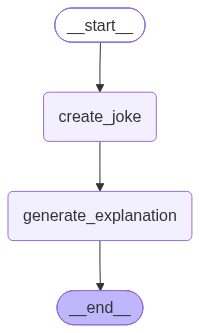

In [8]:
graph = StateGraph(JokeState)
graph.add_node('create_joke',create_joke)
graph.add_node('generate_explanation',generate_explanation)

graph.add_edge(START,'create_joke')
graph.add_edge('create_joke',"generate_explanation")
graph.add_edge("generate_explanation",END)

checkpoint = InMemorySaver()

workflow = graph.compile(checkpointer=checkpoint)
workflow

so whenever you implement memory(persistence) we thread id it's mandatory

In [9]:
config = {'configurable':{'thread_id':"1"}}
initial_state = {'topic':'pizza'}
workflow.invoke(initial_state,config=config)

{'topic': 'pizza',
 'joke': "Why did the pizza go to the therapist?\nBecause it had too many toppings and couldn't handle the pressure!",
 'explanation': 'This joke plays on the idea of a pizza having emotions and needing therapy. The punchline serves as a double entendre, as it suggests that the pizza couldn\'t handle the physical weight or "pressure" of all the toppings, as well as the emotional stress or "pressure" of dealing with too many toppings. It\'s a silly and lighthearted way to imagine a pizza seeking help for its problems.'}

In [ ]:
# this will give finala state value
workflow.get_state(config)

StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza go to the therapist?\nBecause it had too many toppings and couldn't handle the pressure!", 'explanation': 'This joke plays on the idea of a pizza having emotions and needing therapy. The punchline serves as a double entendre, as it suggests that the pizza couldn\'t handle the physical weight or "pressure" of all the toppings, as well as the emotional stress or "pressure" of dealing with too many toppings. It\'s a silly and lighthearted way to imagine a pizza seeking help for its problems.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1940c9-6fff-610c-8002-cd921e53882d'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-09T16:08:41.907005+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1940c9-5682-6094-8001-a972cbff09cc'}}, tasks=(), interrupts=())

In [ ]:
# this will give me every check_point  state value called intermediate value
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza go to the therapist?\nBecause it had too many toppings and couldn't handle the pressure!", 'explanation': 'This joke plays on the idea of a pizza having emotions and needing therapy. The punchline serves as a double entendre, as it suggests that the pizza couldn\'t handle the physical weight or "pressure" of all the toppings, as well as the emotional stress or "pressure" of dealing with too many toppings. It\'s a silly and lighthearted way to imagine a pizza seeking help for its problems.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1940c9-6fff-610c-8002-cd921e53882d'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-09T16:08:41.907005+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1940c9-5682-6094-8001-a972cbff09cc'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'jok

In [ ]:
# so None means we resume not starting from beging and checkpoint_id this tell us from where we need to start simple
workflow.invoke(None,{"configurable":{"thread_id":"1","checkpoint_id":"1f1940c9-3e1f-6f38-8000-81af804189d3"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the doctor? \n\nBecause it was feeling a little crusty!',
 'explanation': 'This joke plays on the double meaning of "crusty." While "crusty" can refer to the texture of the outer layer of a pizza, it can also be used to describe someone who is irritable or in a bad mood. In this case, the pizza went to the doctor because it was feeling "crusty" in the sense of being irritable, not because it needed medical attention for its crust. The humor comes from the unexpected use of the word "crusty" and the irony of a pizza seeking medical help for a mood rather than a physical ailment.'}